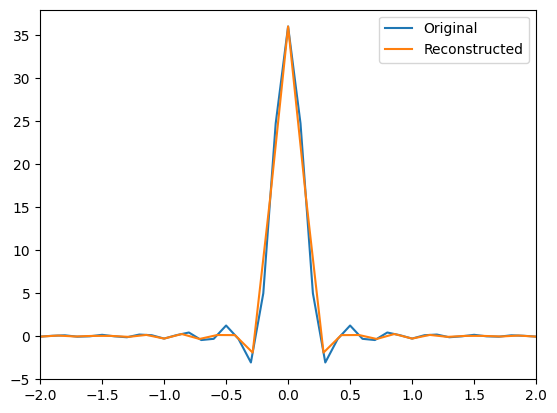

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df = 0.001
f0 = 3

f = np.arange(-5,5,df)

X = np.where( np.abs(f) < f0 , f0**2 - f**2, 0)

x = np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(X))) * len(f) * df
t = np.fft.fftshift(np.fft.fftfreq(len(f),df))

fs = 7
T = 1/fs
t_sampled = np.arange(-5,5,T)
x_sampled = np.interp(t_sampled,t,np.real(x))

X_sampled = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x_sampled))) * T
f_sampled = np.fft.fftshift(np.fft.fftfreq(len(t_sampled),T))

X_reconstructed = X_sampled.copy()
X_reconstructed[np.abs(f_sampled) > fs/2] = 0 

x_reconstructed = np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(X_reconstructed))) / T  

plt.plot(t, np.real(x), label='Original')
plt.plot(t_sampled, np.real(x_reconstructed), label='Reconstructed')
plt.xlim(-2, 2)
plt.legend()
plt.show()